# 06 - Visual Transformer (DenseNet-121) for Brain Tumor Detection

This notebook implements **Visual Transformer** 

In [1]:
import os
import sys
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from dotenv import load_dotenv

# Add src directory to path
sys.path.append(os.path.abspath(os.path.join('..')))
from src.models import ViTModel
from src.training import train_advanced_cnn_with_early_stopping
from src.evaluation import evaluate_cnn_model

%matplotlib inline
sns.set_theme(style="whitegrid")
load_dotenv()

True

## 1. Load Augmented Tensors & Split into Train / Validation / Test

In [2]:
import os
import torch
from sklearn.model_selection import train_test_split
from dotenv import load_dotenv

load_dotenv()
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("data", "processed"))
AUG_DIR_224x224 = os.path.join(PROCESSED_DIR, "augmented_images_224x224")

# Gestion du chemin si on est dans le dossier notebooks/
if not os.path.exists(AUG_DIR_224x224):
    AUG_DIR_224x224 = os.path.join("..", "data", "processed", "augmented_images_224x224")

yes_dir = os.path.join(AUG_DIR_224x224, "yes")
no_dir = os.path.join(AUG_DIR_224x224, "no")

images = []
labels = []

# Chargement des images sans tumeur (Label 0)
if os.path.exists(no_dir):
    for file in os.listdir(no_dir):
        if file.endswith('.pt'):
            tensor_path = os.path.join(no_dir, file)
            images.append(torch.load(tensor_path))
            labels.append(0)

# Chargement des images avec tumeur (Label 1)
if os.path.exists(yes_dir):
    for file in os.listdir(yes_dir):
        if file.endswith('.pt'):
            tensor_path = os.path.join(yes_dir, file)
            images.append(torch.load(tensor_path))
            labels.append(1)

print(f"✅ Total de tenseurs .pt chargés à l'unité : {len(images)}")

# Séparation stratifiée : 70% Train, 15% Validation (pour l'Early Stopping), 15% Test
X_temp, X_test, y_temp, y_test = train_test_split(images, labels, test_size=0.15, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1764, random_state=42, stratify=y_temp)

print(f"📦 Train set : {len(X_train)} | Validation set : {len(X_val)} | Test set : {len(X_test)}")

✅ Total de tenseurs .pt chargés à l'unité : 504
📦 Train set : 352 | Validation set : 76 | Test set : 76


## 2. Initialize and Train Virtual Transformer Model
We use a lower learning rate (`2e-5`) with AdamW to carefully fine-tune the pre-trained weights without destabilizing feature extractors.

In [3]:
# Exemple d'instanciation et d'entraînement du Vision Transformer avec votre pipeline existant
print("=== Initialisation du Vision Transformer (ViT) ===")
vit_model = ViTModel(num_classes=2, freeze_base=False)

# Entraînement avec l'early stopping et un learning rate très fin (les Transformers aiment les petits LR)
trained_vit, history_vit, best_acc_vit = train_advanced_cnn_with_early_stopping(
    model=vit_model, 
    train_images=X_train, train_labels=y_train,
    val_images=X_val, val_labels=y_val, 
    optimizer_type='AdamW',
    lr=0.00002,           # Learning rate très faible car les ViT s'instabilisent vite en fine-tuning
    epochs=30, 
    batch_size=16,        # Batch size plus petit (ex: 16) car les ViT consomment beaucoup de mémoire VRAM
    patience=8
)

print(f"\nViT Best Validation Accuracy: {best_acc_vit:.2f}%")

=== Initialisation du Vision Transformer (ViT) ===
 Chargement des poids locaux ViT-B/16 depuis : ../models\vit_b_16-c867db91.pth
Epoch [1/30] | Train Loss: 0.4195 | Val Accuracy: 94.74%
   ✨ Meilleure accuracy validation : 94.74% (Poids sauvegardés)
Epoch [2/30] | Train Loss: 0.0769 | Val Accuracy: 97.37%
   ✨ Meilleure accuracy validation : 97.37% (Poids sauvegardés)
Epoch [3/30] | Train Loss: 0.0137 | Val Accuracy: 98.68%
   ✨ Meilleure accuracy validation : 98.68% (Poids sauvegardés)
Epoch [4/30] | Train Loss: 0.0040 | Val Accuracy: 98.68%
   ⏳ Stagnation (1/8)
Epoch [5/30] | Train Loss: 0.0235 | Val Accuracy: 94.74%
   ⏳ Stagnation (2/8)
Epoch [6/30] | Train Loss: 0.0375 | Val Accuracy: 86.84%
   ⏳ Stagnation (3/8)
Epoch [7/30] | Train Loss: 0.0214 | Val Accuracy: 97.37%
   ⏳ Stagnation (4/8)
Epoch [8/30] | Train Loss: 0.0024 | Val Accuracy: 97.37%
   ⏳ Stagnation (5/8)
Epoch [9/30] | Train Loss: 0.0018 | Val Accuracy: 98.68%
   ⏳ Stagnation (6/8)
Epoch [10/30] | Train Loss: 0.001

## 3. Comprehensive Test Evaluation & Metrics (Accuracy, Precision, Recall, F1-Score)

In [9]:
metrics_ViT, preds_ViT, true_ViT = evaluate_cnn_model(trained_vit, X_test, y_test)
transfer_df = pd.DataFrame([
    {
        "Model": "ViT (Virtual Transformer)",
        "Accuracy": metrics_ViT["Accuracy"],
        "Precision": metrics_ViT["Precision"],
        "Recall": metrics_ViT["Recall"],
        "F1-Score": metrics_ViT["F1-Score"]
    }
])

print("=== ViT PERFORMANCE SUMMARY ===")
display(transfer_df.style.background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], cmap='Greens'))

=== ViT PERFORMANCE SUMMARY ===


,Model,Accuracy,Precision,Recall,F1-Score
0,ViT (Virtual Transformer),1.000000,1.000000,1.000000,1.000000


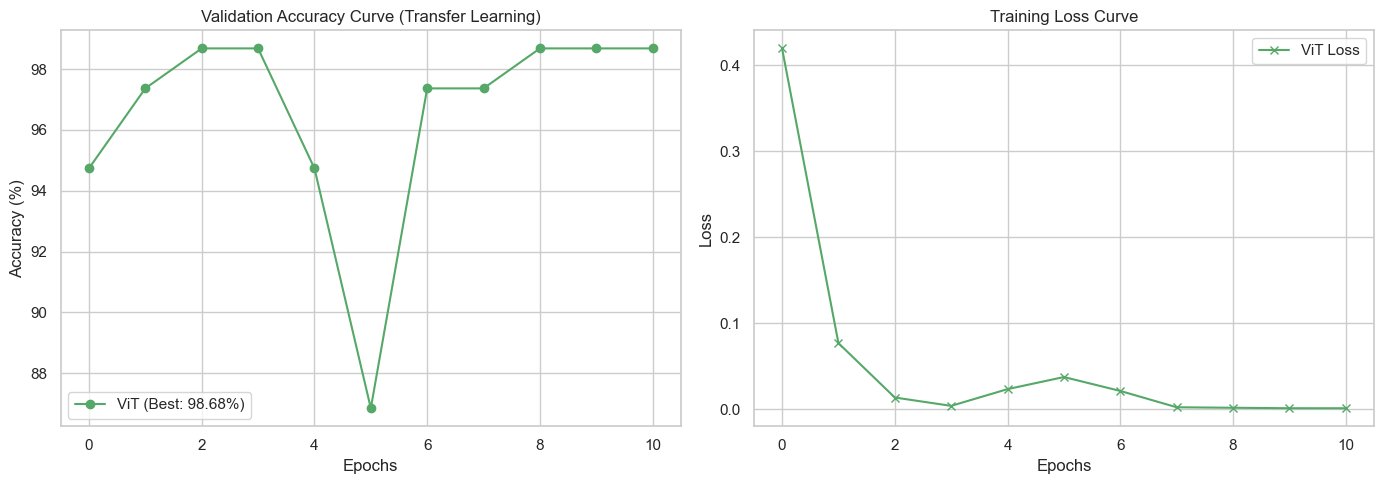

<Figure size 500x400 with 0 Axes>

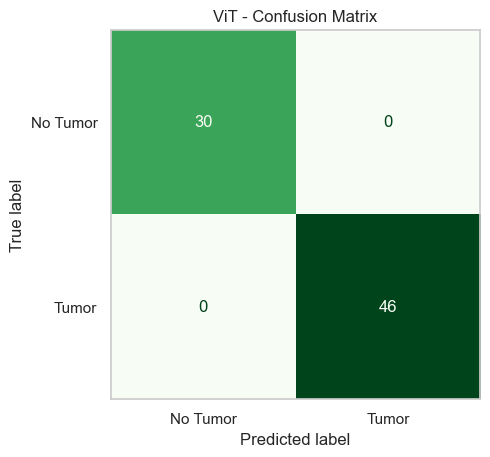

In [ ]:
plt.figure(figsize=(14, 5))

# Validation Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history_vit['val_accuracy'], marker='o', color='g', label=f'ViT (Best: {max(history_vit["val_accuracy"]):.2f}%)')
plt.title('Validation Accuracy Curve (Transfer Learning)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Training Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history_vit['train_loss'], marker='x', color='g', label='ViT Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=metrics_ViT["Confusion Matrix"], display_labels=['No Tumor', 'Tumor']).plot(colorbar=False, cmap='Greens')
plt.title('ViT - Confusion Matrix')
plt.grid(False)
plt.show()

In [12]:
import os
import torch

# Définition du dossier de sauvegarde
save_dir = os.path.join("..", "models")
if not os.path.exists(save_dir):
    save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

# Dictionnaire associant le nom du fichier aux variables potentielles de vos notebooks
models_to_save = {
    "vit_b_16_retrained.pth": locals().get("trained_vit", None)
}

saved_count = 0
print("💾 Sauvegarde des modèles entraînés en cours...")

for filename, model_instance in models_to_save.items():
    if model_instance is not None:
        file_path = os.path.join(save_dir, filename)
        # Sauvegarde des poids (recommandé par rapport au modèle complet)
        torch.save(model_instance.state_dict(), file_path)
        print(f"   ✅ Sauvegardé : {file_path}")
        saved_count += 1

print(f"\n✨ Opération terminée ! {saved_count} modèle(s) sauvegardé(s) dans '{save_dir}'.")

💾 Sauvegarde des modèles entraînés en cours...
   ✅ Sauvegardé : ..\models\vit_b_16_retrained.pth

✨ Opération terminée ! 1 modèle(s) sauvegardé(s) dans '..\models'.
